Using local dataset at: C:\Users\nina-\iCloudDrive\Documenten Nina\Data Science and Society\Early thesis proposal\THESIS MS\MS dataset
    ID Gender Age Age of onset EDSS MRI-EDSS < 2 months Types of Medicines  \
0    1      F  56           43    3                  No            Gelenia   
1    2      F  29           19  1.5                  No            Gelenia   
2    3      F  15            8    4                  No            Tysabri   
3    4      F  24           20    6                  No            Tysabri   
4    5      F  33           31    0                  No             Avonex   
5    6      F  44           40    5                  No             Avonex   
6    7      M  43           40  3.5                  No          Betaferon   
7    8      F  32           30    1                  No            Gelenia   
8    9      F  36           33    6                  No            Gelenia   
9   10      F  39           35    3                  No          Betaferon   
10  11 

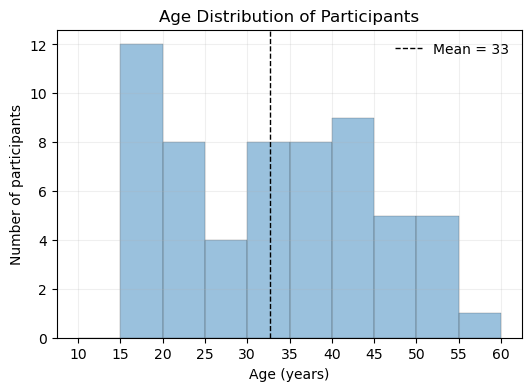

15 56


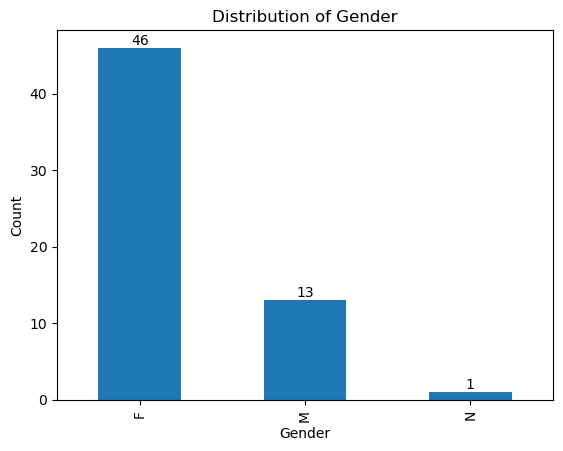


=== Summary Statistics for T2 Sequence Parameters ===
              Parameter    Min     Max    Mean     Std
0               TR (ms)  15.00  620.00  393.92  149.44
1               TE (ms)   1.85   15.00    7.10    3.24
2  Slice thickness (mm)   3.00    6.00    4.93    0.38
3    Slice spacing (mm)   4.72    8.68    6.24    0.74


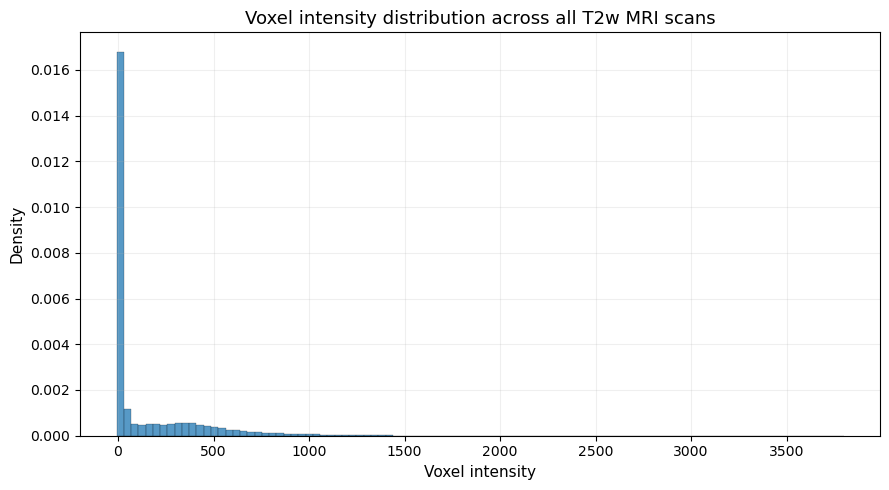

In [34]:
import kagglehub 
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

LOCAL_DATASET_DIR = Path(r"C:\Users\nina-\iCloudDrive\Documenten Nina\Data Science and Society\Early thesis proposal\THESIS MS\MS dataset")

if LOCAL_DATASET_DIR.exists():
    dataset_dir = LOCAL_DATASET_DIR
    print("Using local dataset at:", dataset_dir)
else:
    print("Dataset not found locally. Attempting to download from Kaggle...")
    dataset_dir = Path(kagglehub.dataset_download("orvile/multiple-sclerosis-brain-mri-lesion-segmentation"))
    print("Dataset downloaded to:", dataset_dir)

# patient info data
patient_info_path = os.path.join(dataset_dir, "Supplementary Table 1 for patient info.xlsx")
patient_info = pd.read_excel(patient_info_path)
patient_info = patient_info.iloc[1:].reset_index(drop=True)
patient_info.shape[1]
patient_info.columns = [
    "ID", "Gender", "Age", "Age of onset", "EDSS",
    "MRI-EDSS < 2 months", "Types of Medicines",
    "Presenting Symptom", "Co-morbidity",
    "Pyramidal", "Cerebella", "Brain stem", "Sensory",
    "Sphincters", "Visual", "Mental", "Speech",
    "Motor System", "Sensory System", "Coordination",
    "Gait", "Bowel and bladder function", "Mobility",
    "Mental State", "Optic discs", "Fields",
    "Nystagmus", "Ocular Movement", "Swallowing"
]
print(patient_info)

print("\n=== Missing Values per Column ===")
missing = patient_info.isna().sum()
print(missing[missing > 0])  

print("\n=== Data Info ===")
patient_info.info()

print("\n=== Duplicate Rows ===")
duplicates = patient_info[patient_info.duplicated()]
print(f"Number of duplicate rows: {len(duplicates)}")


patient_info["Motor System"] = pd.to_numeric(
    patient_info["Motor System"], errors="coerce"
)
print("\n=== 'Motor System' Value Counts ===")
print(patient_info["Motor System"].value_counts(dropna=False))

# age distribution plot 
mean_age = patient_info["Age"].mean()
mean_age_rounded = round(mean_age)
age = patient_info["Age"].dropna()

bins = np.arange(10, 61, 5)  

plt.figure(figsize=(6,4))
plt.hist(
    age,
    bins=bins,
    color="#1f77b4",         
    alpha=0.45,              
    edgecolor="black",
    linewidth=0.3
)
plt.title("Age Distribution of Participants")
plt.xlabel("Age (years)")
plt.ylabel("Number of participants")

plt.xticks(bins) 

plt.axvline(
    mean_age,
    linestyle="--",
    linewidth=1,
    color="black",
    label=f"Mean = {round(mean_age)}"
)

plt.legend(loc='upper right', frameon=False)

plt.grid(alpha=0.2)

plt.show()
min_age = patient_info["Age"].min()
max_age = patient_info["Age"].max()

print(min_age, max_age)


# distribution of gender
counts = patient_info["Gender"].value_counts(dropna=False)

plt.figure()
ax = counts.plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Distribution of Gender")

for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.show()

# sequence parameters data 
sequence_parameters_path = os.path.join(dataset_dir, "Supplementary Table 2 for  sequence parameters.xlsx")
df = pd.read_excel(sequence_parameters_path, header=None)
df.columns = df.iloc[0].fillna('') + " " + df.iloc[1].fillna('')
df = df.iloc[2:].reset_index(drop=True)
#print(df)
df_t2 = df.iloc[2:, -4:].copy()

df_t2.columns = ["TR", "TE", "Slice_thickness", "Slice_spacing"]
for col in df_t2.columns:
    df_t2[col] = (
        df_t2[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

summary = pd.DataFrame({
    "Parameter": ["TR (ms)", "TE (ms)", "Slice thickness (mm)", "Slice spacing (mm)"],
    "Min": [df_t2["TR"].min(), df_t2["TE"].min(), df_t2["Slice_thickness"].min(), df_t2["Slice_spacing"].min()],
    "Max": [df_t2["TR"].max(), df_t2["TE"].max(), df_t2["Slice_thickness"].max(), df_t2["Slice_spacing"].max()],
    "Mean": [df_t2["TR"].mean(), df_t2["TE"].mean(), df_t2["Slice_thickness"].mean(), df_t2["Slice_spacing"].mean()],
    "Std": [df_t2["TR"].std(), df_t2["TE"].std(), df_t2["Slice_thickness"].std(), df_t2["Slice_spacing"].std()]
}).round(2)

print("\n=== Summary Statistics for T2 Sequence Parameters ===")
print(summary)

# Voxel intensity distribution
patients = sorted(
    [p for p in os.listdir(dataset_dir) if p.startswith("Patient")],
    key=lambda x: int(x.split("-")[1])
)
t2_voxels = []
for patient in patients:
    patient_number = int(patient.split("-")[1])
    t2_path = os.path.join(dataset_dir, patient, f"{patient_number}-T2.nii")
    
    if os.path.exists(t2_path):
        img = nib.load(t2_path)
        data = img.get_fdata()
        t2_voxels.append(data.flatten())
data_t2 = np.concatenate(t2_voxels)

def plot_histogram(data, name):
    voxels = data.flatten()
    plt.figure(figsize=(9,5))

    plt.hist(
        voxels,
        bins=100,
        density=True,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.2
    )
    plt.title(
        f"Voxel intensity distribution across all {name} MRI scans",
        fontsize=13
    )
    plt.xlabel("Voxel intensity", fontsize=11)
    plt.ylabel("Density", fontsize=11)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
plot_histogram(data_t2, "T2w")

